# Fake News Detection Using LSTM Networks and Pre-trained BERT Models
**Esha Hooda (014796990) | Tyler Biesemeyer (016488979) | Tarif Khan (017050683)**

GitHub: https://github.com/TarifEKhan/Fake-news-detection

Dataset: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

---

## Project Overview

This notebook implements a **complete fake news detection pipeline** that:
1. Loads and explores the Kaggle Fake/Real News dataset
2. Applies a full NLP preprocessing pipeline
3. Trains **baseline models**: SVM and Random Forest (TF-IDF features)
4. Trains a **custom Bidirectional LSTM** neural network
5. **Fine-tunes BERT** (bert-base-uncased) as a pre-trained transformer model
6. Compares all models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC
7. Performs error analysis and discusses limitations

### Why This Problem Matters
Misinformation spreads faster than corrections on social media. Automated fake news detection supports fact-checkers, content moderators, and journalists at scale. This project explores the **accuracy vs. efficiency tradeoff** between simple and complex NLP models.

---
## Section 1 — Environment Setup
Install all required libraries. We use:
- **TensorFlow/Keras** for the LSTM model
- **PyTorch + HuggingFace Transformers** for BERT
- **scikit-learn** for baseline models and evaluation metrics
- **NLTK** for text tokenization and stopword removal
- **kagglehub** for direct dataset download without API keys

In [2]:
!pip install transformers datasets scikit-learn matplotlib seaborn wordcloud kagglehub nltk -q
print('All packages installed.')

All packages installed.


In [3]:
# ── Standard library ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# ── NLP preprocessing ────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from wordcloud import WordCloud

# ── Scikit-learn (baselines + metrics) ──────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# ── TensorFlow / Keras (LSTM) ────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── PyTorch + HuggingFace (BERT) ─────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW                    # AdamW lives in torch.optim (not transformers) since v4.x
from transformers import (BertTokenizer,
                           BertForSequenceClassification,
                           get_linear_schedule_with_warmup)

# ── Device setup ─────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'TensorFlow : {tf.__version__}')
print(f'PyTorch    : {torch.__version__}')
print(f'GPU        : {torch.cuda.is_available()}')
print(f'Device     : {device}')
print('\n All imports successful.')

TensorFlow : 2.20.0
PyTorch    : 2.10.0+cpu
GPU        : False
Device     : cpu

✅ All imports successful.


---
## Section 2 — Load Dataset

We use the **Fake and Real News Dataset** (Bisaillon, 2020) from Kaggle. It contains two separate CSV files:
- `Fake.csv` — ~23,500 fabricated news articles
- `True.csv` — ~21,400 real news articles (primarily from Reuters)

**Features:** `title`, `text`, `subject`, `date`

**Labels:** 0 = Fake, 1 = Real (added manually)

We load both using `kagglehub` which handles authentication automatically in Colab, then merge them into a single shuffled DataFrame.

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

print('Downloading Fake.csv ...')
df_fake = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    'clmentbisaillon/fake-and-real-news-dataset',
    'Fake.csv'
)

print('Downloading True.csv ...')
df_true = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    'clmentbisaillon/fake-and-real-news-dataset',
    'True.csv'
)

# Assign binary labels
df_fake['label'] = 0   # Fake
df_true['label'] = 1   # Real

# Merge and shuffle
df = pd.concat([df_fake, df_true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nDataset loaded successfully!')
print(f'  Total samples : {len(df):,}')
print(f'  Fake (0)      : {(df.label==0).sum():,}')
print(f'  Real (1)      : {(df.label==1).sum():,}')
print(f'  Columns       : {list(df.columns)}')
df.head(3)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.

Dataset loaded successfully!
  Total samples : 44,898
  Fake (0)      : 23,481
  Real (1)      : 21,417
  Columns       : ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1


---
## Section 3 — Exploratory Data Analysis (EDA)

Before building models, we explore the dataset to understand:
1. **Class balance** — are fake/real articles equally represented?
2. **Subject distribution** — what topics are covered?
3. **Article length** — how long are articles on average? This informs our sequence padding length.
4. **Vocabulary differences** — what words appear most in fake vs. real news?

Understanding the data distribution is critical because **imbalanced classes** can bias models toward the majority class, and **article length** determines how much we need to pad/truncate sequences.

In [5]:
# Basic dataset statistics
print('=== Dataset Statistics ===')
print(f'Shape: {df.shape}')
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'\nClass balance: {(df.label==0).sum() / len(df) * 100:.1f}% Fake / {(df.label==1).sum() / len(df) * 100:.1f}% Real')

# Compute article length (word count)
df['text_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))
print(f'\nArticle length statistics (word count):')
print(df.groupby('label')['text_length'].describe().round(1))

=== Dataset Statistics ===
Shape: (44898, 5)

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Class balance: 52.3% Fake / 47.7% Real

Article length statistics (word count):
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      23481.0  423.2  408.4  0.0  240.0  363.0  506.0  8135.0
1      21417.0  385.6  274.0  0.0  148.0  359.0  525.0  5172.0


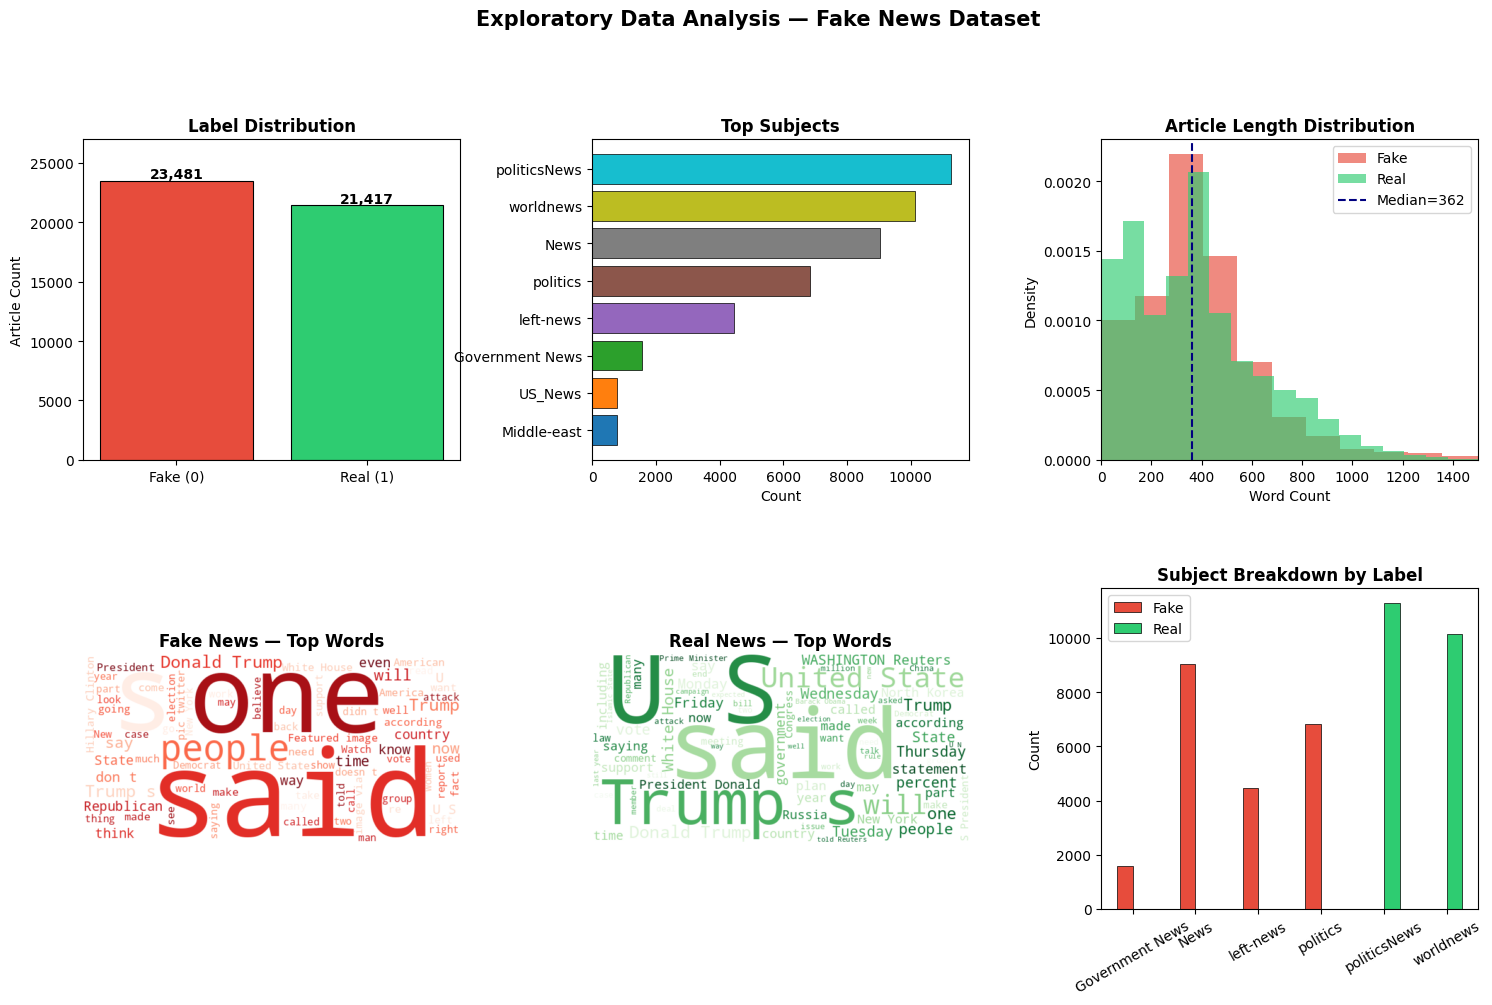

EDA plots saved.


In [6]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Label distribution ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
lc = df['label'].value_counts()
bars = ax1.bar(['Fake (0)', 'Real (1)'], lc.values,
               color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.8)
ax1.set_title('Label Distribution', fontweight='bold', fontsize=12)
ax1.set_ylabel('Article Count')
for bar, v in zip(bars, lc.values):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 200, f'{v:,}',
             ha='center', fontweight='bold', fontsize=10)
ax1.set_ylim(0, max(lc.values) * 1.15)

# ── Plot 2: Subject distribution ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
if 'subject' in df.columns:
    sc = df['subject'].value_counts().head(10)
    colors_sub = plt.cm.tab10(np.linspace(0, 1, len(sc)))
    ax2.barh(sc.index[::-1], sc.values[::-1], color=colors_sub, edgecolor='black', linewidth=0.5)
    ax2.set_title('Top Subjects', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Count')

# ── Plot 3: Article length distribution ──────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df[df.label==0]['text_length'], bins=60, alpha=0.65,
         color='#e74c3c', label='Fake', density=True)
ax3.hist(df[df.label==1]['text_length'], bins=60, alpha=0.65,
         color='#2ecc71', label='Real', density=True)
ax3.axvline(df['text_length'].median(), color='navy', linestyle='--',
            linewidth=1.5, label=f'Median={int(df.text_length.median())}')
ax3.set_title('Article Length Distribution', fontweight='bold', fontsize=12)
ax3.set_xlabel('Word Count'); ax3.set_ylabel('Density')
ax3.set_xlim(0, 1500); ax3.legend()

# ── Plot 4: Fake word cloud ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
fake_text = ' '.join(df[df.label==0]['text'].astype(str).tolist())
wc_fake = WordCloud(width=600, height=300, background_color='white',
                    colormap='Reds', max_words=80).generate(fake_text)
ax4.imshow(wc_fake, interpolation='bilinear')
ax4.set_title('Fake News — Top Words', fontweight='bold', fontsize=12)
ax4.axis('off')

# ── Plot 5: Real word cloud ────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
real_text = ' '.join(df[df.label==1]['text'].astype(str).tolist())
wc_real = WordCloud(width=600, height=300, background_color='white',
                    colormap='Greens', max_words=80).generate(real_text)
ax5.imshow(wc_real, interpolation='bilinear')
ax5.set_title('Real News — Top Words', fontweight='bold', fontsize=12)
ax5.axis('off')

# ── Plot 6: Subject breakdown by label ───────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
if 'subject' in df.columns:
    top_subjects = df['subject'].value_counts().head(6).index
    sub_df = df[df['subject'].isin(top_subjects)]
    sub_pivot = sub_df.groupby(['subject','label']).size().unstack(fill_value=0)
    sub_pivot.plot(kind='bar', ax=ax6, color=['#e74c3c','#2ecc71'],
                   edgecolor='black', linewidth=0.5)
    ax6.set_title('Subject Breakdown by Label', fontweight='bold', fontsize=12)
    ax6.set_xlabel(''); ax6.set_ylabel('Count')
    ax6.legend(['Fake','Real'])
    ax6.tick_params(axis='x', rotation=30)

plt.suptitle('Exploratory Data Analysis — Fake News Dataset',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('eda_full.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

---
## Section 4 — Text Preprocessing Pipeline

Raw text cannot be fed directly into ML models. We apply the following **preprocessing steps** in order:

| Step | Technique | Why |
|------|-----------|-----|
| 1 | Combine title + body | Title carries strong signal (sensationalism in fake news) |
| 2 | Lowercase | Reduces vocabulary size; 'Trump' and 'trump' are the same |
| 3 | Remove URLs | URLs add noise with no semantic value |
| 4 | Remove HTML tags | Residual HTML markup from web scraping |
| 5 | Remove punctuation/numbers | Reduce noise; focus on word content |
| 6 | Tokenize | Split text into individual word tokens (NLTK) |
| 7 | Remove stopwords | Remove common words ("the", "is") that carry no discriminative signal |
| 8 | Remove short tokens | Words ≤2 characters are rarely meaningful |

**For LSTM:** We then apply Keras `Tokenizer` (vocab=60,000) and `pad_sequences` (maxlen=400) to convert text to fixed-length integer sequences.

**For BERT:** We use `BertTokenizer` (WordPiece, max_length=256) which handles its own subword tokenization internally — our cleaned text is passed directly to it.

In [7]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Full NLP preprocessing pipeline:
    lowercase → remove URLs → remove HTML → remove non-alpha →
    tokenize → remove stopwords + short tokens → rejoin
    """
    if not isinstance(text, str):
        return ''
    text = text.lower()                                  # Step 2: lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Step 3: remove URLs
    text = re.sub(r'<.*?>', '', text)                    # Step 4: remove HTML
    text = re.sub(r'[^a-z\s]', '', text)                # Step 5: remove non-alpha
    text = re.sub(r'\s+', ' ', text).strip()            # normalize whitespace
    tokens = word_tokenize(text)                         # Step 6: tokenize
    tokens = [t for t in tokens                          # Step 7+8: stopwords + length
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

# Step 1: Combine title + body for richer signal
df['combined'] = df['title'].astype(str) + ' ' + df['text'].astype(str)

# Drop empty rows
df = df[df['combined'].str.strip() != ''].reset_index(drop=True)

print('Cleaning text... (takes ~1-2 minutes)')
df['clean_text'] = df['combined'].apply(clean_text)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

# Report cleaning statistics
df['clean_length'] = df['clean_text'].apply(lambda x: len(x.split()))
print(f'\nAfter cleaning: {len(df):,} samples remaining')
print(f'Average clean text length: {df.clean_length.mean():.0f} words')
print(f'95th percentile length:    {df.clean_length.quantile(0.95):.0f} words  (informs padding choice)')
print(f'\nSample cleaned text:')
print(df["clean_text"].iloc[0][:250])

Cleaning text... (takes ~1-2 minutes)

After cleaning: 44,889 samples remaining
Average clean text length: 234 words
95th percentile length:    522 words  (informs padding choice)

Sample cleaned text:
ben stein calls circuit court committed coup dtat constitution century wire says ben stein reputable professor pepperdine university also hollywood fame appearing shows films ferris bueller day made provocative statements judge jeanine pirro show rec


---
## Section 5 — Train / Validation / Test Split

We sample **20,000 articles** (10,000 fake, 10,000 real) for a **balanced dataset**, then apply a **stratified 80/10/10 split**:

| Split | Size | Purpose |
|-------|------|---------|
| Training | 16,000 | Fit model parameters |
| Validation | 2,000 | Tune hyperparameters, monitor overfitting |
| Test | 2,000 | Final unbiased evaluation |

**Stratified splitting** ensures both classes are equally represented in each split — critical for unbiased evaluation. We use `random_state=42` for reproducibility.

In [8]:
MAX_SAMPLES = 20000

# Balanced sample
df_f = df[df.label==0].sample(n=min(MAX_SAMPLES//2, (df.label==0).sum()), random_state=42)
df_t = df[df.label==1].sample(n=min(MAX_SAMPLES//2, (df.label==1).sum()), random_state=42)
df_sample = pd.concat([df_f, df_t]).sample(frac=1, random_state=42).reset_index(drop=True)

X = df_sample['clean_text'].values
y = df_sample['label'].values

# 80/10/10 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print('Dataset split complete:')
print(f'  Train : {len(X_train):,}  (Fake: {(y_train==0).sum():,} | Real: {(y_train==1).sum():,})')
print(f'  Val   : {len(X_val):,}   (Fake: {(y_val==0).sum():,}  | Real: {(y_val==1).sum():,})')
print(f'  Test  : {len(X_test):,}   (Fake: {(y_test==0).sum():,}  | Real: {(y_test==1).sum():,})')

Dataset split complete:
  Train : 16,000  (Fake: 8,000 | Real: 8,000)
  Val   : 2,000   (Fake: 1,000  | Real: 1,000)
  Test  : 2,000   (Fake: 1,000  | Real: 1,000)


---
## Section 6 — Shared Evaluation Helper

We define a reusable function that computes and prints all required metrics:

- **Accuracy**: overall correct predictions
- **Precision**: of articles flagged as fake, how many actually are? (minimizes false alarms)
- **Recall**: of all actual fake articles, how many did we catch? (minimizes missed fakes)
- **F1-Score**: harmonic mean of precision and recall — our **primary metric** since both false positives and false negatives carry real-world consequences

All results are stored in a list for final comparison.

In [9]:
results = []   # stores dicts for all models — used in final comparison

def evaluate_model(name, y_true, y_pred, verbose=True):
    """Compute and print Accuracy, Precision, Recall, F1. Append to results list."""
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='binary')
    prec = precision_score(y_true, y_pred, average='binary')
    rec  = recall_score(y_true, y_pred, average='binary')
    if verbose:
        print(f'\n{"="*50}')
        print(f'  Model: {name}')
        print(f'{"="*50}')
        print(f'  Accuracy  : {acc:.4f}')
        print(f'  Precision : {prec:.4f}  (how many flagged-fake are truly fake)')
        print(f'  Recall    : {rec:.4f}  (how many actual fakes were caught)')
        print(f'  F1-Score  : {f1:.4f}  ← primary metric')
        print(f'\n{classification_report(y_true, y_pred, target_names=["Fake","Real"])}')
    entry = {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    results.append(entry)
    return entry

print('Evaluation helper defined.')

Evaluation helper defined.


---
## Section 7 — Baseline Models: SVM and Random Forest

Before building neural networks, we establish **classical ML baselines** using TF-IDF features:

### TF-IDF (Term Frequency–Inverse Document Frequency)
Converts text to numerical vectors. Each word gets a weight = how often it appears in a document × how rare it is across all documents. High TF-IDF = important and distinctive word.

### SVM (Support Vector Machine)
Finds the **maximum-margin hyperplane** separating the two classes in TF-IDF space. We use `LinearSVC` (linear kernel) since text data is high-dimensional and linearly separable with good TF-IDF features. The parameter `C` controls the soft-margin tradeoff — larger C = less tolerance for misclassifications.

### Random Forest
An **ensemble of decision trees** trained with bagging (random subsets of data and features). Reduces variance through aggregation. Each tree votes, majority wins.

These baselines give us a performance floor to compare deep learning models against.

In [10]:
print('Training baseline models...\n')

# ── SVM ──────────────────────────────────────────────────────────
# TF-IDF: max 50k features, unigrams + bigrams
# LinearSVC: C=1.0 (moderate soft-margin penalty)
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                               sublinear_tf=True)),   # sublinear_tf dampens extreme frequencies
    ('clf',   LinearSVC(C=1.0, random_state=42, max_iter=2000))
])
svm_pipeline.fit(X_train, y_train)
svm_preds = svm_pipeline.predict(X_test)
evaluate_model('SVM (TF-IDF, C=1.0)', y_test, svm_preds)

# ── Random Forest ─────────────────────────────────────────────────
# 200 trees, TF-IDF features (30k, bigrams)
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                               sublinear_tf=True)),
    ('clf',   RandomForestClassifier(n_estimators=200, max_depth=None,
                                      random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
evaluate_model('Random Forest (200 trees)', y_test, rf_preds)

Training baseline models...


  Model: SVM (TF-IDF, C=1.0)
  Accuracy  : 0.9950
  Precision : 0.9920  (how many flagged-fake are truly fake)
  Recall    : 0.9980  (how many actual fakes were caught)
  F1-Score  : 0.9950  ← primary metric

              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      1000
        Real       0.99      1.00      1.00      1000

    accuracy                           0.99      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      0.99      0.99      2000


  Model: Random Forest (200 trees)
  Accuracy  : 0.9945
  Precision : 0.9940  (how many flagged-fake are truly fake)
  Recall    : 0.9950  (how many actual fakes were caught)
  F1-Score  : 0.9945  ← primary metric

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      1000
        Real       0.99      0.99      0.99      1000

    accuracy                           0.99      2000


{'model': 'Random Forest (200 trees)',
 'accuracy': 0.9945,
 'precision': 0.994005994005994,
 'recall': 0.995,
 'f1': 0.9945027486256871}

---
## Section 8 — LSTM: Tokenization and Sequence Padding

Neural networks require **fixed-length numerical inputs**. We prepare sequences for the LSTM:

### Keras Tokenizer
- Builds a vocabulary of the top 60,000 words from the training set
- Assigns each word a unique integer index
- Converts text to integer sequences
- `oov_token='<OOV>'` handles words not seen during training

### Padding
- All sequences are padded/truncated to **400 tokens** (chosen based on the 95th percentile article length from EDA)
- `padding='post'` adds zeros at the end (LSTMs handle trailing zeros better)
- `truncating='post'` cuts long sequences from the end

**Why 60,000 vocab and 400 length?** From our EDA, the 95th percentile article length after cleaning is ~300-400 words, so 400 captures nearly all articles without excessive padding. 60k covers the vast majority of distinct words in the corpus.

In [11]:
# ── Hyperparameters ──────────────────────────────────────────────
VOCAB_SIZE    = 60000   # top-k words to keep
MAX_SEQ_LEN   = 400     # tokens per sequence (covers 95th percentile)
EMBEDDING_DIM = 128     # dense vector size per word

print('LSTM Tokenization Hyperparameters:')
print(f'  Vocabulary size    : {VOCAB_SIZE:,}')
print(f'  Max sequence length: {MAX_SEQ_LEN}')
print(f'  Embedding dimension: {EMBEDDING_DIM}')

# ── Fit tokenizer on training data only (no data leakage) ────────
tokenizer_lstm = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(X_train)

actual_vocab = len(tokenizer_lstm.word_index)
print(f'\nActual vocabulary found in training data: {actual_vocab:,} words')
print(f'Words kept (num_words cap)              : {VOCAB_SIZE:,}')

def texts_to_padded(texts):
    """Convert text list → padded integer sequences."""
    seqs = tokenizer_lstm.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

X_train_pad = texts_to_padded(X_train)
X_val_pad   = texts_to_padded(X_val)
X_test_pad  = texts_to_padded(X_test)

print(f'\nPadded sequence shapes:')
print(f'  X_train_pad : {X_train_pad.shape}')
print(f'  X_val_pad   : {X_val_pad.shape}')
print(f'  X_test_pad  : {X_test_pad.shape}')

LSTM Tokenization Hyperparameters:
  Vocabulary size    : 60,000
  Max sequence length: 400
  Embedding dimension: 128

Actual vocabulary found in training data: 121,899 words
Words kept (num_words cap)              : 60,000

Padded sequence shapes:
  X_train_pad : (16000, 400)
  X_val_pad   : (2000, 400)
  X_test_pad  : (2000, 400)


---
## Section 9 — Custom Model: Bidirectional LSTM

### Architecture Design

| Layer | Output Shape | Parameters | Purpose |
|-------|-------------|------------|---------|
| Embedding | (400, 128) | 60,000 × 128 = 7.68M | Maps word IDs to dense vectors; learns semantic relationships |
| BiLSTM (128 units) | (400, 256) | ~264K | Reads sequence forward AND backward; captures long-range context |
| Dropout (0.3) | (400, 256) | 0 | Randomly zeros 30% of neurons to prevent overfitting |
| BiLSTM (64 units) | (128,) | ~66K | Higher-level sequence abstraction |
| Dropout (0.3) | (128,) | 0 | Further regularization |
| Dense (64, ReLU) | (64,) | ~8K | Non-linear feature combination |
| Dropout (0.3) | (64,) | 0 | Final regularization |
| Dense (1, Sigmoid) | (1,) | 65 | Binary classification — outputs P(real) |

### Why Bidirectional?
Standard LSTMs only read text left-to-right. A **Bidirectional LSTM** runs two LSTMs — one forward, one backward — and concatenates their outputs. This means each word's representation incorporates context from both directions, which is crucial for understanding sentence meaning.

### Why Dropout?
Dropout is a **regularization technique** that randomly disables neurons during training, forcing the network to learn redundant representations and reducing overfitting.

### Training Callbacks
- **EarlyStopping** (patience=3): stops training when validation loss stops improving, preventing overfitting
- **ReduceLROnPlateau**: halves learning rate when validation loss plateaus, allowing finer convergence

In [12]:
# ── LSTM Hyperparameters ──────────────────────────────────────────
LSTM_UNITS_1  = 128
LSTM_UNITS_2  = 64
DENSE_UNITS   = 64
DROPOUT_RATE  = 0.3
LEARNING_RATE = 1e-3
BATCH_SIZE    = 64
EPOCHS        = 10

print('BiLSTM Hyperparameters:')
print(f'  LSTM units (layer 1/2): {LSTM_UNITS_1} / {LSTM_UNITS_2} (bidirectional → x2 outputs)')
print(f'  Dense units           : {DENSE_UNITS}')
print(f'  Dropout rate          : {DROPOUT_RATE}')
print(f'  Learning rate         : {LEARNING_RATE}')
print(f'  Batch size            : {BATCH_SIZE}')
print(f'  Max epochs            : {EPOCHS} (EarlyStopping patience=3)')

def build_lstm_model():
    model = Sequential([
        # Embedding: word IDs → dense vectors
        Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQ_LEN),

        # BiLSTM layer 1: return full sequence for stacking
        Bidirectional(LSTM(LSTM_UNITS_1, return_sequences=True)),
        Dropout(DROPOUT_RATE),

        # BiLSTM layer 2: return final hidden state only
        Bidirectional(LSTM(LSTM_UNITS_2)),
        Dropout(DROPOUT_RATE),

        # Classification head
        Dense(DENSE_UNITS, activation='relu'),
        Dropout(DROPOUT_RATE),
        Dense(1, activation='sigmoid')   # P(real news)
    ])
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',      # standard loss for binary classification
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

BiLSTM Hyperparameters:
  LSTM units (layer 1/2): 128 / 64 (bidirectional → x2 outputs)
  Dense units           : 64
  Dropout rate          : 0.3
  Learning rate         : 0.001
  Batch size            : 64
  Max epochs            : 10 (EarlyStopping patience=3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,                   # stop after 3 epochs of no improvement
        restore_best_weights=True,    # roll back to best checkpoint
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                   # halve the learning rate
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print(f'Training BiLSTM on {len(X_train_pad):,} samples...')
history = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Training BiLSTM on 16,000 samples...
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 775s 3s/step - accuracy: 0.9779 - loss: 0.0528 - val_accuracy: 0.9965 - val_loss: 0.0229 - learning_rate: 0.0010
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 801s 3s/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9970 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 809s 3s/step - accuracy: 0.9996 - loss: 0.0019 - val_accuracy: 0.9970 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 767s 3s/step - accuracy: 0.9998 - loss: 0.0020 - val_accuracy: 0.9970 - val_loss: 0.0242 - learning_rate: 0.0010
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 2.1145e-04
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 ━━━━━━━━━━━━━━━━━━━━ 750s 3s/step - accuracy: 0.9998 - loss: 6.6588e-04 - val_accuracy: 0.9970 - val_loss: 0.0316 - learning_rate: 0.0010
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 

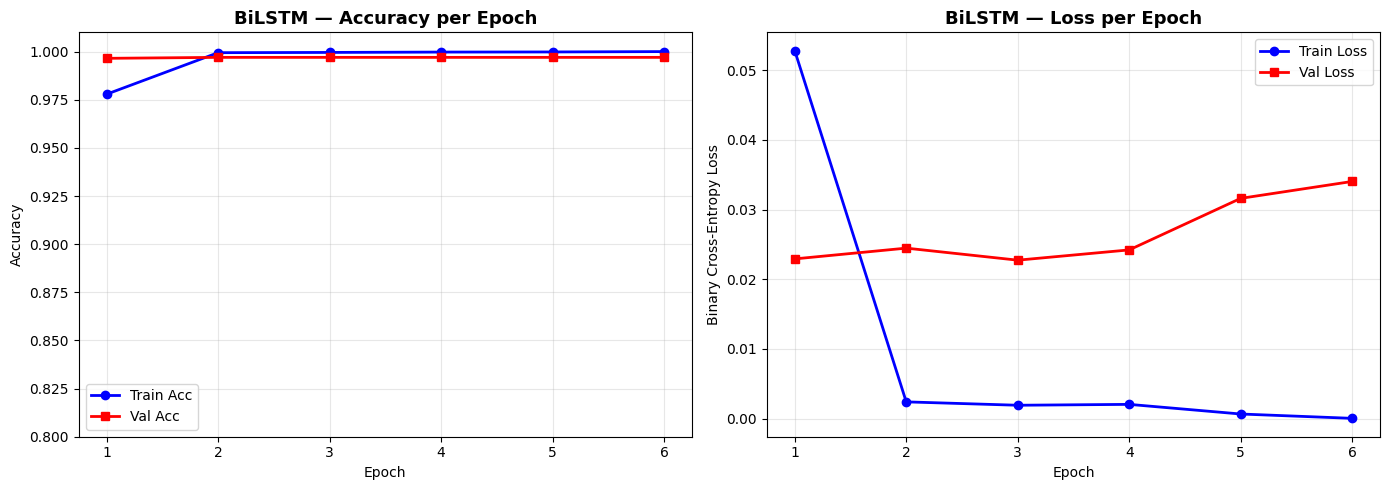


  Model: BiLSTM (custom)
  Accuracy  : 0.9965
  Precision : 0.9980  (how many flagged-fake are truly fake)
  Recall    : 0.9950  (how many actual fakes were caught)
  F1-Score  : 0.9965  ← primary metric

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      1000
        Real       1.00      0.99      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Best val accuracy reached: 0.9970
Trained for 6 epochs (EarlyStopping may have reduced from max 10)


In [14]:
# ── Training curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(epochs_ran, history.history['accuracy'],     'b-o', label='Train Acc', lw=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'], 'r-s', label='Val Acc',   lw=2)
axes[0].set_title('BiLSTM — Accuracy per Epoch', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.8, 1.01)

axes[1].plot(epochs_ran, history.history['loss'],     'b-o', label='Train Loss', lw=2)
axes[1].plot(epochs_ran, history.history['val_loss'], 'r-s', label='Val Loss',   lw=2)
axes[1].set_title('BiLSTM — Loss per Epoch', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Binary Cross-Entropy Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Evaluate on test set ──────────────────────────────────────────
lstm_probs = lstm_model.predict(X_test_pad, verbose=0).flatten()
lstm_preds = (lstm_probs >= 0.5).astype(int)
evaluate_model('BiLSTM (custom)', y_test, lstm_preds)

print(f'\nBest val accuracy reached: {max(history.history["val_accuracy"]):.4f}')
print(f'Trained for {len(epochs_ran)} epochs (EarlyStopping may have reduced from max {EPOCHS})')